🔍 DIAGNOSTIC DE L'ENVIRONNEMENT JUPYTER
🐍 Python executable: /Users/vivienbistrel/AI4Finance/.venv/bin/python
📊 Python version: 3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 17.0.0 (clang-1700.0.13.3)]
📁 Current working directory: /Users/vivienbistrel/AI4Finance/notebooks
🛤️  Python path: ['/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload']...

📦 MODULES INSTALLÉS DANS CET ENVIRONNEMENT:
----------------------------------------
❌ matplotlib: MANQUANT
✅ pandas: DISPONIBLE
✅ numpy: DISPONIBLE
✅ jupyter: DISPONIBLE

🔧 SOLUTION AUTOMATIQUE:
------------------------------
Exécution de l'installation dans cet environnement...
✅ Installation réussie!
🔄 Redémarrage nécessaire du kernel pour prendre effet


In [3]:
# 🚀 INSTALLATION DIRECTE DANS JUPYTER
print("🚀 Installation de matplotlib dans le kernel actuel...")
print("=" * 50)

# Méthode 1: Installation via pip dans le kernel actuel
import sys
!{sys.executable} -m pip install matplotlib

print("\n✅ Installation terminée!")
print("🔄 Redémarrez maintenant le kernel: Kernel → Restart")


🚀 Installation de matplotlib dans le kernel actuel...

✅ Installation terminée!
🔄 Redémarrez maintenant le kernel: Kernel → Restart


## Load the Normalized Data

In [1]:
import pandas as pd 
import numpy as np 

data = pd.read_csv('../data/normalized_data.csv', index_col=0) 

print('Data shape:', data.shape)
print('Data columns:', data.columns.tolist())
print(data.head())

Data shape: (732, 6)
Data columns: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
        Price     Close      High       Low      Open    Volume
1        Date       NaN       NaN       NaN       NaN       NaN
2  2023-09-07 -1.774119 -1.789863 -1.769483 -1.787014 -1.177821
3  2023-09-08 -1.786835 -1.789686 -1.766812 -1.768142 -1.189460
4  2023-09-09 -1.787214 -1.808144 -1.761683 -1.781047 -1.418663
5  2023-09-10 -1.789625 -1.806038 -1.768247 -1.781435 -1.314790


## Create the EMA (Exponential Moving Average)

In [2]:

def calculate_ema(prices, span):
    """
    calculate Exponential Moving Average
    span: number of days to calculate the EMA(e.g. 12, 26)
    """
    
    return prices.ewm(span=span, adjust=False).mean()

# Calculate EMA for different period
data['EMA_12'] = calculate_ema(data['Close'], 12)
data['EMA_26'] = calculate_ema(data['Close'], 26)
data['EMA_50'] = calculate_ema(data['Close'], 50)

data['EMA_Signal'] = data['EMA_12'] - data['EMA_26']
data['Price_to_EMA12'] = data['Close'] / data['EMA_12']
data['Price_to_EMA26'] = data['Close'] / data['EMA_26']
data['Price_to_EMA50'] = data['Close'] / data['EMA_50']

print('EMA features created')
print(data[['Close', 'EMA_12', 'EMA_26', 'EMA_50', 'EMA_Signal', 'Price_to_EMA12', 'Price_to_EMA26', 'Price_to_EMA50']].head())


EMA features created
      Close    EMA_12    EMA_26    EMA_50  EMA_Signal  Price_to_EMA12  \
1       NaN       NaN       NaN       NaN         NaN             NaN   
2 -1.774119 -1.774119 -1.774119 -1.774119    0.000000        1.000000   
3 -1.786835 -1.776076 -1.775061 -1.774618   -0.001014        1.006058   
4 -1.787214 -1.777789 -1.775961 -1.775112   -0.001828        1.005301   
5 -1.789625 -1.779610 -1.776974 -1.775681   -0.002637        1.005628   

   Price_to_EMA26  Price_to_EMA50  
1             NaN             NaN  
2        1.000000        1.000000  
3        1.006633        1.006884  
4        1.006336        1.006818  
5        1.007120        1.007853  


### Plot a graph to display how the different EMA varies with time based on the normalized data

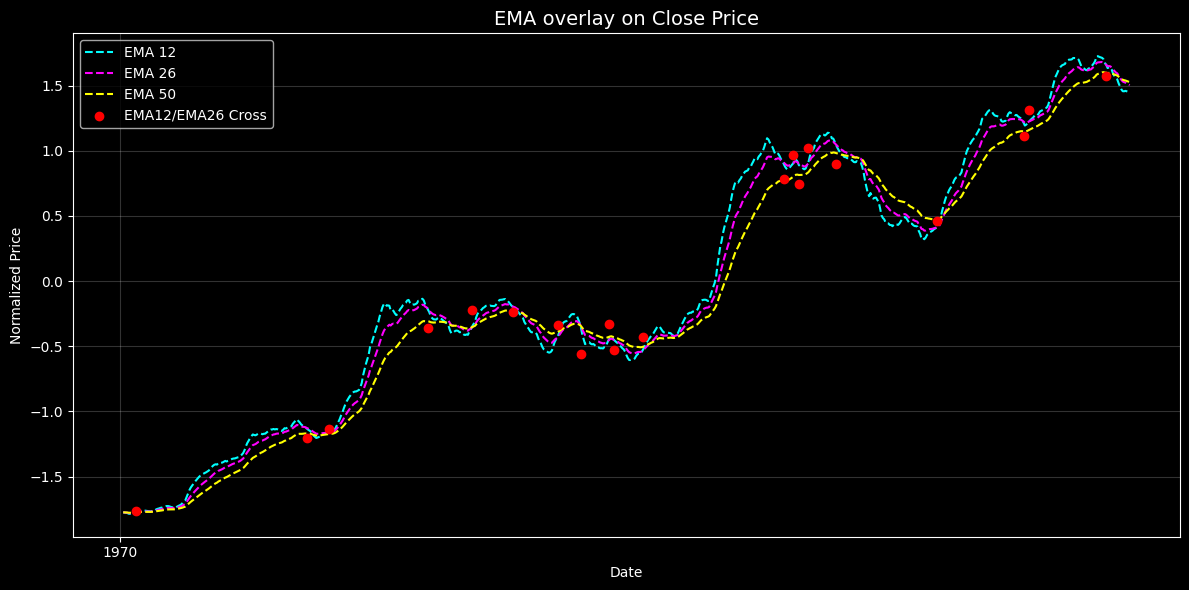

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime index
if not pd.api.types.is_datetime64_any_dtype(data.index):
    data = data.copy()
    data.index = pd.to_datetime(data.index, errors='coerce')
    data = data[~data.index.isna()]

plt.style.use('dark_background')
plt.figure(figsize=(12,6))

# Close price and EMAs
#plt.plot(data.index, data['Close'], label='Close', color='white', linewidth=1.8)
plt.plot(data.index, data['EMA_12'], label='EMA 12', color='cyan', linestyle='--', linewidth=1.5)
plt.plot(data.index, data['EMA_26'], label='EMA 26', color='magenta', linestyle='--', linewidth=1.5)
plt.plot(data.index, data['EMA_50'], label='EMA 50', color='yellow', linestyle='--', linewidth=1.5)

# EMA12/EMA26 cross points (sign change)
cross_points = data[data['EMA_Signal'] * data['EMA_Signal'].shift(1) < 0]
plt.scatter(cross_points.index, cross_points['Close'], color='red', label='EMA12/EMA26 Cross', zorder=30)

plt.title('EMA overlay on Close Price', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## Create RSI(Relative Strength Index)

In [4]:
def calculate_rsi(prices, window=14):
    """
    Calculate the RSI
    window: number of days to calculate the RSI(e.g. 14)
    """

    #price change
    delta  = prices.diff()

    #gain and loss
    gain = delta.where(delta > 0, 0)
    loss = delta.where(delta < 0, 0)

    #average gain and loss using EMA
    avg_gain = gain.ewm(span=window, adjust=False).mean()
    avg_loss = loss.ewm(span=window, adjust=False).mean()

    #Calculate RS
    rs = avg_gain / avg_loss

    #Calculate RSI
    rsi = 100 - (100 / (1 + rs))

    return rsi

#Create RSI features
data['RSI_14'] = calculate_rsi(data['Close'], 14)
data['RSI_7'] = calculate_rsi(data['Close'], 7)

#RSI-based features
data['RSI_Overbought'] = (data['RSI_14'] > 70).astype(int) # if overbought, 0 otherwise
data['RSI_Oversold'] = (data['RSI_14'] < 30).astype(int) # if oversold, 0 otherwise
data['RSI_Neutral'] = ((data['RSI_14'] >= 30) & (data['RSI_14'] <= 70)).astype(int) # if neutral, 1 otherwise

print('RSI features created')
print(data[['Close', 'RSI_14', 'RSI_7', 'RSI_Overbought', 'RSI_Oversold', 'RSI_Neutral']].head(20))



RSI features created
                                  Close       RSI_14        RSI_7  \
1970-01-01 00:00:00.000000001       NaN          NaN          NaN   
1970-01-01 00:00:00.000000002 -1.774119          NaN          NaN   
1970-01-01 00:00:00.000000003 -1.786835     0.000000     0.000000   
1970-01-01 00:00:00.000000004 -1.787214     0.000000     0.000000   
1970-01-01 00:00:00.000000005 -1.789625     0.000000     0.000000   
1970-01-01 00:00:00.000000006 -1.815075     0.000000     0.000000   
1970-01-01 00:00:00.000000007 -1.789583  -439.804824  2946.888722   
1970-01-01 00:00:00.000000008 -1.774571   371.455079   217.934178   
1970-01-01 00:00:00.000000009 -1.762737   214.686936   158.747318   
1970-01-01 00:00:00.000000010 -1.760114   199.926118   151.158627   
1970-01-01 00:00:00.000000011 -1.761650   218.965824   168.111987   
1970-01-01 00:00:00.000000012 -1.762945   241.339099   192.383232   
1970-01-01 00:00:00.000000013 -1.754580   180.256757   141.192928   
1970-01-01 00

Plot a graph 